In [1]:
# Import Library
import re
import string
import pandas as pd
import seaborn as sns

from pathlib import Path
from matplotlib import pyplot as plt
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.model_selection import KFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import cross_validate

In [2]:
# Path Configuration
BASE_DIR = Path(".")
DATA_DIR = BASE_DIR / "../Meta"
RESOURCE_DIR = BASE_DIR / "../Resources"

def validate_files():
    required_files = {
        'dataset': DATA_DIR / "DatasetRempang.csv",
        'normalization': RESOURCE_DIR / "normalization.txt",
        'stopwords': RESOURCE_DIR / "stopwords.txt",
        'rootwords': RESOURCE_DIR / "rootwords.txt",
        'positive': DATA_DIR / "positive.tsv",
        'negative': DATA_DIR / "negative.tsv"
    }
    
    missing_files = []
    for name, path in required_files.items():
        if not path.exists():
            missing_files.append(f"{name}: {path}")
    
    if missing_files:
        print("File tidak ditemukan:")
        for file in missing_files:
            print(f"  - {file}")
        return False
    
    return True

# Validasi file
if validate_files():
    df = pd.read_csv(DATA_DIR / "DatasetRempang.csv")
else:
    print("Program tidak dapat dilanjutkan karena file yang diperlukan tidak ada")


In [3]:
# Sastrawi Stemmer
factory = StemmerFactory()
stemmer = factory.create_stemmer()

# Load normalization dictionary
norm_dict = {}
try:
    with open(RESOURCE_DIR / "normalization.txt", 'r', encoding='utf-8') as f:
        for line in f:
            if ':' in line:
                key, value = line.strip().split(':', 1)
                norm_dict[key.strip()] = value.strip()
    print(f"Kamus normalisasi: {len(norm_dict):,} kata")
except FileNotFoundError:
    print("File normalization.txt tidak ditemukan, normalisasi dilewati")
    norm_dict = {}

# Load Indonesian stopwords
stopwords = set()
try:
    with open(RESOURCE_DIR / "stopwords.txt", 'r', encoding='utf-8') as f:
        for line in f:
            stopwords.add(line.strip().lower())
    print(f"Stopwords: {len(stopwords):,} kata")
except FileNotFoundError:
    print("File stopwords.txt tidak ditemukan, stopword removal dilewati")
    stopwords = set()

# Load root words dictionary
root_words = set()
try:
    with open(RESOURCE_DIR / "rootwords.txt", 'r', encoding='utf-8') as f:
        root_words = {line.strip().lower() for line in f if line.strip()}
    print(f"Kamus Stemming: {len(root_words):,} kata")
except FileNotFoundError:
    print("File rootwords.txt tidak ditemukan, hanya menggunakan Sastrawi")
    root_words = set()

Kamus normalisasi: 103 kata
Stopwords: 845 kata
Kamus Stemming: 28,009 kata


In [4]:
# Preprocessing
def clean_text(text): # Menghapus noise dari teks
    if pd.isna(text) or text == '':
        return ''

    text = str(text)
    
    # Hapus URL/link
    text = re.sub(r'http[s]?://(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    text = re.sub(r'www\.(?:[a-zA-Z]|[0-9]|[$-_@.&+]|[!*\\(\\),]|(?:%[0-9a-fA-F][0-9a-fA-F]))+', '', text)
    
    # Hapus mention dan hashtag
    text = re.sub(r'@[A-Za-z0-9_]+', '', text)
    text = re.sub(r'#[A-Za-z0-9_]+', '', text)
    
    # Hapus emoji dan karakter unicode
    text = re.sub(r'[^\x00-\x7F]+', '', text)
    text = re.sub(r'[\U0001F600-\U0001F64F]', '', text)
    text = re.sub(r'[\U0001F300-\U0001F5FF]', '', text)
    text = re.sub(r'[\U0001F680-\U0001F6FF]', '', text)
    text = re.sub(r'[\U0001F1E0-\U0001F1FF]', '', text)
    
    # Hapus angka dan tanda baca
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub(r'[""''„‚«»]', '', text)
    
    # Hapus spasi berlebih
    text = re.sub(r'\s+', ' ', text)
    text = text.strip()

    return text

def case_folding(text): # Mengubah ke huruf kecil
    if pd.isna(text) or text == '':
        return ''
    return text.lower()

def tokenize_text(text): # Memecah teks menjadi token
    if pd.isna(text) or text == '':
        return []

    tokens = [token.strip() for token in text.split() if token.strip()]
    clean_tokens = []
    for token in tokens:
        token = re.sub(r'[^\w]', '', token)
        if token:
            clean_tokens.append(token)

    return clean_tokens

def normalize_text(tokens, norm_dict): # Normalisasi kata slang/tidak formal"""
    if not tokens:
        return []
    
    normalized = []
    for token in tokens:
        normalized_word = norm_dict.get(token, token)
        normalized.append(normalized_word)
    
    return normalized

def remove_stopwords(tokens, stopwords_set): # Menghapus kata-kata umum
    if not tokens:
        return []
    return [token for token in tokens if token not in stopwords_set]

def basic_preprocess_for_lexicon(text, norm_dict, stopwords_set):
    """Preprocessing untuk lexicon"""
    text = clean_text(text)
    text = case_folding(text)
    tokens = tokenize_text(text)
    tokens = normalize_text(tokens, norm_dict)
    tokens = remove_stopwords(tokens, stopwords_set)
    return ' '.join(tokens)

def stem_tokens(tokens): # Mengubah kata menjadi bentuk dasar
    if not tokens:
        return []
    
    stemmed_tokens = []
    for token in tokens:
        stemmed = sastrawi_stem(token)
        stemmed_tokens.append(stemmed)
    
    return stemmed_tokens

def sastrawi_stem(word):
    word = word.lower().strip()

    if root_words and word in root_words:
        return word
    
    stemmed = stemmer.stem(word)
    
    if root_words and stemmed in root_words:
        return stemmed
    
    if not root_words:
        return stemmed
    
    return stemmed

def full_preprocess_pipeline(text, norm_dict, stopwords_set):
    """Pipeline lengkap preprocessing"""
    text = clean_text(text)
    text = case_folding(text)
    tokens = tokenize_text(text)
    tokens = normalize_text(tokens, norm_dict)
    tokens = remove_stopwords(tokens, stopwords_set)
    tokens = stem_tokens(tokens)  # Stemming di akhir
    
    return ' '.join(tokens)


In [5]:
# Load dan preprocess lexicon
def load_lexicon_from_tsv(negative_path, positive_path):
    lexicon = {}

    try:
        negative_df = pd.read_csv(negative_path, sep='\t')
        print(f"Loading negative words: {len(negative_df)} kata")
        
        for _, row in negative_df.iterrows():
            word = str(row['word']).strip().lower()
            weight = float(row['weight']) if pd.notna(row['weight']) else -1.0
            
            processed_word = basic_preprocess_for_lexicon(word, norm_dict, set())
            if processed_word:
                lexicon[processed_word] = weight
                
    except FileNotFoundError:
        print(f"File {negative_path} tidak ditemukan.")
    except Exception as e:
        print(f"Error loading negative lexicon: {e}")

    try:
        positive_df = pd.read_csv(positive_path, sep='\t')
        print(f"Loading positive words: {len(positive_df)} kata")
        
        for _, row in positive_df.iterrows():
            word = str(row['word']).strip().lower()
            weight = float(row['weight']) if pd.notna(row['weight']) else 1.0
            
            processed_word = basic_preprocess_for_lexicon(word, norm_dict, set())
            if processed_word:
                lexicon[processed_word] = weight

    except FileNotFoundError:
        print(f"File {positive_path} tidak ditemukan.")
    except Exception as e:
        print(f"Error loading positive lexicon: {e}")

    print(f"Total lexicon loaded: {len(lexicon)} kata")
    return lexicon

# Load lexicon yang sudah dipreprocess
inset_lexicon_loaded = load_lexicon_from_tsv(
    DATA_DIR / 'negative.tsv',
    DATA_DIR / 'positive.tsv'
)

Loading negative words: 6609 kata
Loading positive words: 3609 kata
Total lexicon loaded: 9051 kata


In [6]:
# Kolom salinan teks asli
df['original_text'] = df['full_text'].copy()

df['text_for_lexicon'] = df['full_text'].apply(
    lambda x: basic_preprocess_for_lexicon(x, norm_dict, stopwords)
)

def label_sentiment(text, lexicon, threshold=0):
    if not isinstance(text, str) or not text.strip():
        return "unknown"
    
    words = text.lower().split()
    sentiment_score = sum(lexicon.get(word, 0) for word in words)
    
    return "pro" if sentiment_score > threshold else "kontra"

df['label'] = df['text_for_lexicon'].apply(
    lambda x: label_sentiment(x, inset_lexicon_loaded, threshold=0)
)

print("Distribusi label:")
print(df['label'].value_counts())

def safe_preprocess(text):
    try:
        return full_preprocess_pipeline(text, norm_dict, stopwords)
    except Exception as e:
        print(f"Error processing text: {str(text)[:50]}... - {e}")
        return ""

df['full_text'] = df['original_text'].apply(safe_preprocess)

Distribusi label:
label
pro       660
kontra    340
Name: count, dtype: int64


In [7]:
# TF-IDF
vectorizer = TfidfVectorizer(
    max_features=5000,
    min_df=2,
    max_df=0.95,
    stop_words=None,
    ngram_range=(1, 2)
)

X_tfidf = vectorizer.fit_transform(df['full_text'])

df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=vectorizer.get_feature_names_out())
y = df['label']

# Pembagian Data Training-Testing
X_train, X_test, y_train, y_test = train_test_split(
    df_tfidf, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Konversi ke float untuk SMOTE
X_train = X_train.astype(float)
X_test = X_test.astype(float)

print(f"Data split:")
print(f"  Training: {X_train.shape[0]} sampel")
print(f"  Testing: {X_test.shape[0]} sampel")
print(f"  Distribusi training: {y_train.value_counts().to_dict()}")

# Menerapkan SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"Setelah SMOTE:")
print(f"  Distribusi: {pd.Series(y_train_smote).value_counts().to_dict()}")

Data split:
  Training: 700 sampel
  Testing: 300 sampel
  Distribusi training: {'pro': 462, 'kontra': 238}
Setelah SMOTE:
  Distribusi: {'pro': 462, 'kontra': 462}


In [8]:
# Training Model
print("Training Naive Bayes Classifier")

nb_classifier = MultinomialNB()
nb_classifier.fit(X_train_smote, y_train_smote)

print("Naive Bayes berhasil dilatih!")
print(f" Info model:")
print(f"  Jumlah fitur: {X_train_smote.shape[1]:,}")
print(f"  Jumlah sampel training: {X_train_smote.shape[0]:,}")
print(f"  Kelas: {nb_classifier.classes_}")

Training Naive Bayes Classifier
Naive Bayes berhasil dilatih!
 Info model:
  Jumlah fitur: 2,268
  Jumlah sampel training: 924
  Kelas: ['kontra' 'pro']


In [9]:
# Evaluasi Model
print("Evaluasi model pada data testing")

y_pred = nb_classifier.predict(X_test)
accuracy_nb = accuracy_score(y_test, y_pred)

print(f"Akurasi Naive Bayes: {accuracy_nb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Evaluasi model pada data testing
Akurasi Naive Bayes: 0.7633

Classification Report:
              precision    recall  f1-score   support

      kontra       0.60      0.89      0.72       102
         pro       0.93      0.70      0.80       198

    accuracy                           0.76       300
   macro avg       0.76      0.79      0.76       300
weighted avg       0.82      0.76      0.77       300



Cross Validation
Hasil Cross Validation (10-Fold):
  ACCURACY       : 0.7989
  PRECISION_MACRO: 0.8185
  RECALL_MACRO   : 0.8005
  F1_MACRO       : 0.7934


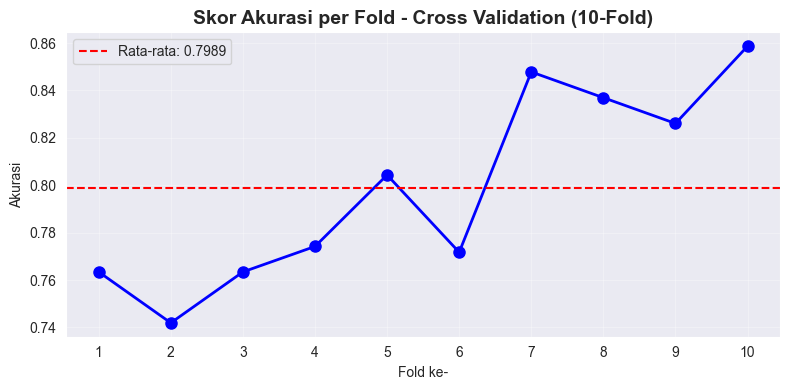

In [10]:
# Cross Validation
print("Cross Validation")

kf = KFold(n_splits=10, shuffle=True, random_state=42)
scoring_metrics = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

cv_results = cross_validate(nb_classifier, X_train_smote, y_train_smote,
                            cv=kf, scoring=scoring_metrics, return_train_score=False)

print("Hasil Cross Validation (10-Fold):")
for metric in scoring_metrics:
    scores = cv_results[f'test_{metric}']
    print(f"  {metric.upper():15}: {scores.mean():.4f}")

# Visualisasi Cross Validation - Akurasi Curve
plt.figure(figsize=(8, 4))

accuracy_scores = cv_results['test_accuracy']
plt.plot(range(1, 11), accuracy_scores, 'bo-', linewidth=2, markersize=8)
plt.axhline(y=accuracy_scores.mean(), color='r', linestyle='--',
            label=f'Rata-rata: {accuracy_scores.mean():.4f}')
plt.title('Skor Akurasi per Fold - Cross Validation (10-Fold)',
          fontsize=14, fontweight='bold')
plt.xlabel('Fold ke-')
plt.ylabel('Akurasi')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(1, 11))

plt.tight_layout()
plt.show()

Confusion Matrix:
[[ 91  11]
 [ 60 138]]


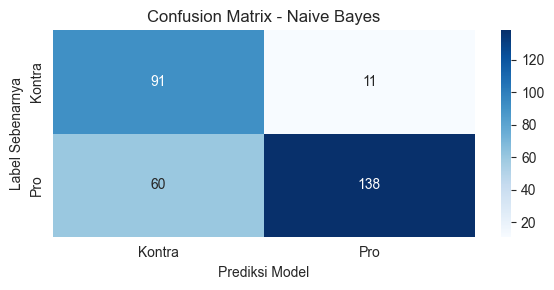

In [11]:
# Confusion Matrix
print("Confusion Matrix:")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 3))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Kontra', 'Pro'],
            yticklabels=['Kontra', 'Pro'])
plt.title('Confusion Matrix - Naive Bayes')
plt.ylabel('Label Sebenarnya')
plt.xlabel('Prediksi Model')
plt.tight_layout()

print(cm)